In [1]:
%pip install gensim rank-bm25 pandas numpy sentence-transformers faiss-cpu Sastrawi

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import re
import numpy as np
import pandas as pd
from collections import Counter

from gensim.models import Word2Vec
from gensim.models.fasttext import load_facebook_vectors

from sentence_transformers import SentenceTransformer
import torch
import faiss

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

c:\Users\dela puspita\Documents\INFORMATIKA SMT 7\SKRIPSI\program\venv-skripsi\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [3]:
DATA_URL = "https://docs.google.com/spreadsheets/d/1gTmTtyRO5SmQsq4_QdB1ZnUdSUNmoNyL7MciKfVdgtE/export?format=csv&gid=527481706"

docs = pd.read_csv(DATA_URL)
docs = docs.reset_index(drop=True)
docs["doc_id"] = docs.index

TEXT_W2V_COL = "text_word2vec"

docs[TEXT_W2V_COL] = docs[TEXT_W2V_COL].fillna("")
print("Kolom dataset:", list(docs.columns))
print("Jumlah dokumen:", len(docs))

docs[["doc_id", "title", "abstract", TEXT_W2V_COL]].head()

Kolom dataset: ['url', 'title', 'abstract', 'faculty', 'department', 'text_semantic', 'text_bm25', 'text_word2vec', 'doc_id']
Jumlah dokumen: 15326


,doc_id,title,abstract,text_word2vec
0,0,PENERAPAN METODE CLARKE AND WRIGHT SAVING HEUR...,Koperasi Kareb Bojonegoro bagian distributor m...,penerapan metode clarke and wright saving heur...
1,1,OPINION SHOPPING SEBAGAI PEMODERASI PENGARUH F...,Penelitian ini bertujuan untuk membuktikan opi...,opinion shopping sebagai pemoderasi pengaruh f...
2,2,PREDIKSI PENYAKIT JANTUNG MENGGUNAKAN ALGORITM...,Penyakit jantung merupakan suatu gangguan pada...,prediksi penyakit jantung menggunakan algoritm...
3,3,IDENTIFIKASI TANDA TANGAN DENGAN METODE CONVOL...,Setiap manusia pasti memiliki tanda tangan yan...,identifikasi tanda tangan dengan metode convol...
4,4,IDENTIFIKASI MATA UANG LOGAM MENGGUNAKAN SEGME...,Uang adalah alat pembayaran yang digunakan seh...,identifikasi mata uang logam menggunakan segme...


In [9]:
def simple_tokenize(text):
    text = str(text).lower()
    return re.findall(r"[a-z0-9_]+", text)

docs_tokens_w2v = [simple_tokenize(t) for t in docs[TEXT_W2V_COL]]

doc_freq = Counter()
for sent in docs_tokens_w2v:
    for tok in set(sent):
        doc_freq[tok] += 1

N_DOCS = len(docs_tokens_w2v)
total_tokens = sum(len(sent) for sent in docs_tokens_w2v)
print("Jumlah dokumen:", len(docs_tokens_w2v))

unique_tokens = set(tok for sent in docs_tokens_w2v for tok in sent)
print("Jumlah token unik:", len(unique_tokens))

avg_tokens = total_tokens / N_DOCS
print("Rata-rata token per dokumen:", avg_tokens)

print("jumlah token", (total_tokens) )

Jumlah dokumen: 15326
Jumlah token unik: 50465
Rata-rata token per dokumen: 191.7639958240898
jumlah token 2938975


In [8]:
FASTTEXT_BIN = "cc.id.300.bin"
ft = load_facebook_vectors(FASTTEXT_BIN)

In [9]:
w2v_model = Word2Vec(
    vector_size=ft.vector_size,
    window=8,
    min_count=5,
    workers=4,
    sg=1,
)

w2v_model.build_vocab(docs_tokens_w2v)

for w in set(w2v_model.wv.key_to_index).intersection(ft.key_to_index):
    w2v_model.wv[w] = ft[w]

w2v_model.train(docs_tokens_w2v, total_examples=len(docs_tokens_w2v), epochs=10)
w2v = w2v_model.wv

In [ ]:

factory = StopWordRemoverFactory()
sastrawi_stopwords = set(factory.get_stop_words())

custom_stopwords = {
    "dan","atau","yang","dengan","pada","di","ke","dari", "untuk","dalam","sebagai","adalah","itu","ini"
}

STOPWORDS = sastrawi_stopwords.union(custom_stopwords)

# ----------------------------
# OPTIONAL: NORMALIZATION
# ----------------------------
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
stemmer = StemmerFactory().create_stemmer()

def normalize(word):
    return stemmer.stem(word.lower())


# ----------------------------
# PREFIX RULE
# ----------------------------
COMMON_PREFIXES = ("me", "di", "pe", "ke", "ber", "ter")

def is_morphological_variant(base, cand):
    for p in COMMON_PREFIXES:
        if cand.startswith(p) and cand[len(p):] == base:
            return True
    return False


# ----------------------------
# MAIN FILTER QE
# ----------------------------
def is_valid(
    word,
    base_tokens,
    min_df=5,
    max_df_ratio=0.15
):
    w = normalize(word)

    if w in [normalize(bt) for bt in base_tokens]:
        return False

    if w in STOPWORDS:
        return False

    if word.isdigit() or len(word) < 3:
        return False

    if doc_freq.get(word, 0) < min_df:
        return False

    if doc_freq.get(word, 0) / N_DOCS > max_df_ratio:
        return False

    for bt in base_tokens:
        if is_morphological_variant(normalize(bt), w):
            return False

    return True

In [29]:
def expand_query_hybrid(query):
    base = simple_tokenize(query)
    exp = []

    for t in base:
        if t in w2v:
            cands = w2v.most_similar(t, topn=20)
        elif t in ft:
            cands = ft.most_similar(t, topn=20)
        else:
            continue

        for c, s in cands:
            if s < 0.6:
                continue
            if not is_valid(c, base):
                continue
            if c not in exp:
                exp.append(c)

    return base + exp


def expand_query_hybrid_no_filter(query):
    base = simple_tokenize(query)
    exp = []

    for t in base:
        if t in w2v:
            cands = w2v.most_similar(t, topn=20)
        elif t in ft:
            cands = ft.most_similar(t, topn=20)
        else:
            continue

        for c, s in cands:
            if s > 0.6 and c not in exp:
                exp.append(c)

    return base + exp

In [30]:
model = SentenceTransformer("indosbert_finetuned_title_abs", device=DEVICE)

index = faiss.read_index("indexes_finetuned/semantic_index.faiss")
doc_ids = np.load("indexes_finetuned/doc_ids.npy")

In [31]:
def search(query, topk=10):
    # pastikan query string
    if isinstance(query, list):
        query = " ".join(query)

    emb = model.encode([query], normalize_embeddings=True)
    scores, idx = index.search(emb, topk)

    ranked_ids = [int(doc_ids[i]) for i in idx[0]]

    res = pd.DataFrame({
        "doc_id": ranked_ids,
        "score": scores[0]
    })

    res = res.merge(docs[["doc_id","title","url"]], on="doc_id", how="left")

    res["rank"] = range(1, len(res)+1)

    return res[["rank","doc_id","title","url","score"]]

In [118]:
# =========================
# SCENARIO 1: FT (NO QE)
# =========================

q = "iot"

emb = model.encode([q], normalize_embeddings=True)
scores, idx = index.search(emb, 10)

ids = [int(doc_ids[i]) for i in idx[0]]

res = pd.DataFrame({"doc_id": ids, "score": scores[0]})
res = res.merge(docs[["doc_id","title","url"]], on="doc_id")
res["rank"] = range(1, len(res)+1)

pd.set_option('display.max_colwidth', None)
res

,doc_id,score,title,url,rank
0,5089,0.405545,Pengembangan Platform IoT Cerdas dengan Trigger Action Programming dan Canvas API berbasis Android,https://repository.upnjatim.ac.id/24019/,1
1,1601,0.373803,APLIKASI INDIKATOR PERGERAKAN HARGA PADA CRYPTOCURRENCY BERBASIS PIVOT POINT,https://repository.upnjatim.ac.id/15003/,2
2,8348,0.373374,APLIKASI INFORMASI ARBITRASI CRYPTOCURRENCY ANTAR MARKET BERBASIS API DAN PHP,https://repository.upnjatim.ac.id/3379/,3
3,15182,0.366540,SISTEM PRESENSI FINGERPRINT PORTABLE BERBASIS IOT MENGGUNAKAN ALGORITMA EKSTRAKSI SIDIK JARI MINUTIAE BASED,https://repository.upnjatim.ac.id/959/,4
4,4534,0.365753,UPAYA INTERNATIONAL ORGANIZATION FOR MIGRATION (IOM) DALAM MENANGANI INTERNALLY DISPLACED PERSONS (IDPs) DI UKRAINA PASCA ANEKSASI KRIMEA OLEH RUSIA TAHUN 2014-2017,https://repository.upnjatim.ac.id/22958/,5
5,12702,0.357917,APLIKASI AKUN DEMO TRADING CRYPTOCURRENCY MENGGUNAKAN METODE PRICE AND TIME PRIORITY,https://repository.upnjatim.ac.id/4902/,6
6,3824,0.339690,EVALUASI USER EXPERIENCE APLIKASI DIGITAL BANKING JENIUS MENGGUNAKAN METODE USER EXPERIENCE QUESTIONNAIRE (UEQ),https://repository.upnjatim.ac.id/20501/,7
7,12719,0.338769,INDIKATOR ANALISA PERGERAKAN CRYPTOCURRENCY BERBASIS FIBONACCI,https://repository.upnjatim.ac.id/4926/,8
8,10737,0.319834,Perbandingan Diplomasi Publik Indonesia Pada Asian Games 2018 Dan Piala Dunia U-17 Tahun 2023,https://repository.upnjatim.ac.id/39704/,9
9,8304,0.314075,Adam dan SGD pada Faster RCNN ResNet dan MobileNet untuk Deteksi Gestur Tangan Bahasa Isyarat,https://repository.upnjatim.ac.id/33609/,10


In [119]:
# =========================
# SCENARIO 2: HYBRID QE (NO FILTER)
# =========================

q = "iot"

tokens = simple_tokenize(q)
exp = []

for t in tokens:
    if t in w2v:
        cands = w2v.most_similar(t, topn=10)
    elif t in ft:
        cands = ft.most_similar(t, topn=10)
    else:
        continue

    for c, s in cands:
        if s > 0.6 and c not in exp:
            exp.append(c)

expanded = " ".join(tokens + exp)

print("Expanded:", expanded)

emb = model.encode([expanded], normalize_embeddings=True)
scores, idx = index.search(emb, 10)

ids = [int(doc_ids[i]) for i in idx[0]]

res = pd.DataFrame({"doc_id": ids, "score": scores[0]})
res = res.merge(docs[["doc_id","title","url"]], on="doc_id")
res["rank"] = range(1, len(res)+1)

res

Expanded: iot things esp32 mikrokontroler wemos nodemcu kontroler mqtt itclab logic blynk


,doc_id,score,title,url,rank
0,3740,0.512599,Model Predictive Control (MPC) pada Sistem Kendali Suhu iTCLab dan Pemantauannya Menggunakan Internet Of Things (IOT),https://repository.upnjatim.ac.id/20355/,1
1,6117,0.435915,Implementasi Algoritma SMOTE Dan Klasifikasi Decision Tree Untuk Mendeteksi Kecurangan Transaksi Online,https://repository.upnjatim.ac.id/26578/,2
2,694,0.422750,DESAIN DAN PURWARUPA GIM EDUKASI TEORI PEMROGRAMAN DASAR MENGGUNAKAN METODE BLOCK-BASED PROGRAMMING,https://repository.upnjatim.ac.id/11734/,3
3,12331,0.417126,Implementasi Extreme Learning Machine dan Explainable Artificial Intelligence Pada Deteksi Fraud Transaksi Pembayaran Online PT. XYZ,https://repository.upnjatim.ac.id/43831/,4
4,12719,0.411895,INDIKATOR ANALISA PERGERAKAN CRYPTOCURRENCY BERBASIS FIBONACCI,https://repository.upnjatim.ac.id/4926/,5
5,10146,0.396351,Pengembangan Sistem Pembaruan Firmware Over-the-Air untuk Perangkat IoT Berbasis ESP32 dengan Integrasi MQTT dan HTTP,https://repository.upnjatim.ac.id/38581/,6
6,6206,0.385592,DETEKSI ANOMALI MENGGUNAKAN ENSEMBLE LEARNING DAN RANDOM OVERSAMPLING PADA PENIPUAN TRANSAKSI KEUANGAN,https://repository.upnjatim.ac.id/26753/,7
7,3824,0.384961,EVALUASI USER EXPERIENCE APLIKASI DIGITAL BANKING JENIUS MENGGUNAKAN METODE USER EXPERIENCE QUESTIONNAIRE (UEQ),https://repository.upnjatim.ac.id/20501/,8
8,3161,0.384390,PROTOTIPE APLIKASI PEMANFAATAN SENSOR GAS DALAM PENCEGAHAN KEBAKARAN BERBASIS MIKROKONTROLER,https://repository.upnjatim.ac.id/19325/,9
9,2139,0.377060,ANALISIS USER EXPERIENCE PENGGUNA LEARNING MANAGEMENT SYSTEM MENGGUNAKAN METODE HEART METRIC (STUDI KASUS : PROGRAM STUDI INDEPENDEN SEAL),https://repository.upnjatim.ac.id/16444/,10


In [120]:
# =========================
# SCENARIO 3: HYBRID QE + FILTER
# =========================

q = "iot"

tokens = simple_tokenize(q)
exp = []

for t in tokens:
    if t in w2v:
        cands = w2v.most_similar(t, topn=10)
    elif t in ft:
        cands = ft.most_similar(t, topn=10)
    else:
        continue

    for c, s in cands:
        if s < 0.6:
            continue
        if not is_valid(c, tokens):
            continue
        if c in exp:
            continue
        exp.append(c)

expanded = " ".join(tokens + exp)

print("Expanded:", expanded)

emb = model.encode([expanded], normalize_embeddings=True)
scores, idx = index.search(emb, 10)

ids = [int(doc_ids[i]) for i in idx[0]]

res = pd.DataFrame({"doc_id": ids, "score": scores[0]})
res = res.merge(docs[["doc_id","title","url"]], on="doc_id")
res["rank"] = range(1, len(res)+1)

res

Expanded: iot things esp32 mikrokontroler nodemcu mqtt logic blynk


,doc_id,score,title,url,rank
0,10146,0.479939,Pengembangan Sistem Pembaruan Firmware Over-the-Air untuk Perangkat IoT Berbasis ESP32 dengan Integrasi MQTT dan HTTP,https://repository.upnjatim.ac.id/38581/,1
1,10709,0.413078,ANALISIS PERBANDINGAN PERFORMASI ANTARA METODE PCC (PER CONNECTION CLASSIFIER) DENGAN ECMP (EQUAL COST MULTI-PATH) PADA JARINGAN AKSES INTERNET MENGGUNAKAN MIKROTIK ROUTER OS,https://repository.upnjatim.ac.id/39645/,2
2,5089,0.408209,Pengembangan Platform IoT Cerdas dengan Trigger Action Programming dan Canvas API berbasis Android,https://repository.upnjatim.ac.id/24019/,3
3,4074,0.403895,SISTEM MONITORING DETAK JANTUNG BERBASIS FUZZY DENGAN IoT MQTT PANEL,https://repository.upnjatim.ac.id/2112/,4
4,12331,0.401175,Implementasi Extreme Learning Machine dan Explainable Artificial Intelligence Pada Deteksi Fraud Transaksi Pembayaran Online PT. XYZ,https://repository.upnjatim.ac.id/43831/,5
5,3824,0.401060,EVALUASI USER EXPERIENCE APLIKASI DIGITAL BANKING JENIUS MENGGUNAKAN METODE USER EXPERIENCE QUESTIONNAIRE (UEQ),https://repository.upnjatim.ac.id/20501/,6
6,14880,0.390390,PROTOTIPE SISTEM OTOMATIS MINI WEATHER STATION MENGGUNAKAN NODEMCU BERBASIS INTERNET OF THINGS,https://repository.upnjatim.ac.id/874/,7
7,3161,0.389475,PROTOTIPE APLIKASI PEMANFAATAN SENSOR GAS DALAM PENCEGAHAN KEBAKARAN BERBASIS MIKROKONTROLER,https://repository.upnjatim.ac.id/19325/,8
8,6117,0.384106,Implementasi Algoritma SMOTE Dan Klasifikasi Decision Tree Untuk Mendeteksi Kecurangan Transaksi Online,https://repository.upnjatim.ac.id/26578/,9
9,694,0.379702,DESAIN DAN PURWARUPA GIM EDUKASI TEORI PEMROGRAMAN DASAR MENGGUNAKAN METODE BLOCK-BASED PROGRAMMING,https://repository.upnjatim.ac.id/11734/,10


In [121]:
# =========================
# SCENARIO 4: W2V QE (NO FILTER)
# =========================

q = "iot"

tokens = simple_tokenize(q)
exp = []

for t in tokens:
    if t in w2v:
        for c, s in w2v.most_similar(t, topn=10):
            if s > 0.6 and c not in exp:
                exp.append(c)

expanded = " ".join(tokens + exp)

print("Expanded:", expanded)

emb = model.encode([expanded], normalize_embeddings=True)
scores, idx = index.search(emb, 10)

ids = [int(doc_ids[i]) for i in idx[0]]

res = pd.DataFrame({"doc_id": ids, "score": scores[0]})
res = res.merge(docs[["doc_id","title","url"]], on="doc_id")
res["rank"] = range(1, len(res)+1)

res

Expanded: iot things esp32 mikrokontroler wemos nodemcu kontroler mqtt itclab logic blynk


,doc_id,score,title,url,rank
0,3740,0.512599,Model Predictive Control (MPC) pada Sistem Kendali Suhu iTCLab dan Pemantauannya Menggunakan Internet Of Things (IOT),https://repository.upnjatim.ac.id/20355/,1
1,6117,0.435915,Implementasi Algoritma SMOTE Dan Klasifikasi Decision Tree Untuk Mendeteksi Kecurangan Transaksi Online,https://repository.upnjatim.ac.id/26578/,2
2,694,0.422750,DESAIN DAN PURWARUPA GIM EDUKASI TEORI PEMROGRAMAN DASAR MENGGUNAKAN METODE BLOCK-BASED PROGRAMMING,https://repository.upnjatim.ac.id/11734/,3
3,12331,0.417126,Implementasi Extreme Learning Machine dan Explainable Artificial Intelligence Pada Deteksi Fraud Transaksi Pembayaran Online PT. XYZ,https://repository.upnjatim.ac.id/43831/,4
4,12719,0.411895,INDIKATOR ANALISA PERGERAKAN CRYPTOCURRENCY BERBASIS FIBONACCI,https://repository.upnjatim.ac.id/4926/,5
5,10146,0.396351,Pengembangan Sistem Pembaruan Firmware Over-the-Air untuk Perangkat IoT Berbasis ESP32 dengan Integrasi MQTT dan HTTP,https://repository.upnjatim.ac.id/38581/,6
6,6206,0.385592,DETEKSI ANOMALI MENGGUNAKAN ENSEMBLE LEARNING DAN RANDOM OVERSAMPLING PADA PENIPUAN TRANSAKSI KEUANGAN,https://repository.upnjatim.ac.id/26753/,7
7,3824,0.384961,EVALUASI USER EXPERIENCE APLIKASI DIGITAL BANKING JENIUS MENGGUNAKAN METODE USER EXPERIENCE QUESTIONNAIRE (UEQ),https://repository.upnjatim.ac.id/20501/,8
8,3161,0.384390,PROTOTIPE APLIKASI PEMANFAATAN SENSOR GAS DALAM PENCEGAHAN KEBAKARAN BERBASIS MIKROKONTROLER,https://repository.upnjatim.ac.id/19325/,9
9,2139,0.377060,ANALISIS USER EXPERIENCE PENGGUNA LEARNING MANAGEMENT SYSTEM MENGGUNAKAN METODE HEART METRIC (STUDI KASUS : PROGRAM STUDI INDEPENDEN SEAL),https://repository.upnjatim.ac.id/16444/,10


In [122]:
# =========================
# SCENARIO 5: W2V ONLY FILTER
# =========================

q = "iot"

tokens = simple_tokenize(q)
exp = []

for t in tokens:
    if t in w2v:
        for c, s in w2v.most_similar(t, topn=10):

            if s < 0.6:
                continue

            # 🔥 FILTER MASUK DI SINI
            if not is_valid(c, tokens):
                continue

            if c in exp:
                continue

            exp.append(c)

expanded = " ".join(tokens + exp)

print("Expanded:", expanded)

emb = model.encode([expanded], normalize_embeddings=True)
scores, idx = index.search(emb, 10)

ids = [int(doc_ids[i]) for i in idx[0]]

res = pd.DataFrame({"doc_id": ids, "score": scores[0]})
res = res.merge(docs[["doc_id","title","url"]], on="doc_id")
res["rank"] = range(1, len(res)+1)

res

Expanded: iot things esp32 mikrokontroler nodemcu mqtt logic blynk


,doc_id,score,title,url,rank
0,10146,0.479939,Pengembangan Sistem Pembaruan Firmware Over-the-Air untuk Perangkat IoT Berbasis ESP32 dengan Integrasi MQTT dan HTTP,https://repository.upnjatim.ac.id/38581/,1
1,10709,0.413078,ANALISIS PERBANDINGAN PERFORMASI ANTARA METODE PCC (PER CONNECTION CLASSIFIER) DENGAN ECMP (EQUAL COST MULTI-PATH) PADA JARINGAN AKSES INTERNET MENGGUNAKAN MIKROTIK ROUTER OS,https://repository.upnjatim.ac.id/39645/,2
2,5089,0.408209,Pengembangan Platform IoT Cerdas dengan Trigger Action Programming dan Canvas API berbasis Android,https://repository.upnjatim.ac.id/24019/,3
3,4074,0.403895,SISTEM MONITORING DETAK JANTUNG BERBASIS FUZZY DENGAN IoT MQTT PANEL,https://repository.upnjatim.ac.id/2112/,4
4,12331,0.401175,Implementasi Extreme Learning Machine dan Explainable Artificial Intelligence Pada Deteksi Fraud Transaksi Pembayaran Online PT. XYZ,https://repository.upnjatim.ac.id/43831/,5
5,3824,0.401060,EVALUASI USER EXPERIENCE APLIKASI DIGITAL BANKING JENIUS MENGGUNAKAN METODE USER EXPERIENCE QUESTIONNAIRE (UEQ),https://repository.upnjatim.ac.id/20501/,6
6,14880,0.390390,PROTOTIPE SISTEM OTOMATIS MINI WEATHER STATION MENGGUNAKAN NODEMCU BERBASIS INTERNET OF THINGS,https://repository.upnjatim.ac.id/874/,7
7,3161,0.389475,PROTOTIPE APLIKASI PEMANFAATAN SENSOR GAS DALAM PENCEGAHAN KEBAKARAN BERBASIS MIKROKONTROLER,https://repository.upnjatim.ac.id/19325/,8
8,6117,0.384106,Implementasi Algoritma SMOTE Dan Klasifikasi Decision Tree Untuk Mendeteksi Kecurangan Transaksi Online,https://repository.upnjatim.ac.id/26578/,9
9,694,0.379702,DESAIN DAN PURWARUPA GIM EDUKASI TEORI PEMROGRAMAN DASAR MENGGUNAKAN METODE BLOCK-BASED PROGRAMMING,https://repository.upnjatim.ac.id/11734/,10


In [123]:
# =========================
# SCENARIO 6: FASTTEXT ONLY
# =========================

q = "iot"

tokens = simple_tokenize(q)
exp = []

for t in tokens:
    if t in ft:
        for c, s in ft.most_similar(t, topn=10):
            if s > 0.6 and c not in exp:
                exp.append(c)

expanded = " ".join(tokens + exp)

print("Expanded:", expanded)

emb = model.encode([expanded], normalize_embeddings=True)
scores, idx = index.search(emb, 10)

ids = [int(doc_ids[i]) for i in idx[0]]

res = pd.DataFrame({"doc_id": ids, "score": scores[0]})
res = res.merge(docs[["doc_id","title","url"]], on="doc_id")
res["rank"] = range(1, len(res)+1)

res

Expanded: iot BSHRA coa-pic LUSSO XP-31 imppk CB31R MozDex PF4 V.41 Bog-o


,doc_id,score,title,url,rank
0,7851,0.337778,Analisis Penerimaan Audiens Terhadap Gerakan Boikot Produk Israel Pada Akun Instagram @gerakanbds,https://repository.upnjatim.ac.id/32576/,1
1,5732,0.322072,PERANCANGAN UI/UX APLIKASI MARKETPLACE BARBERSHOP CUTSPLACE MENGGUNAKAN METODE DESIGN THINKING (Studi Kasus : Pangkas Rambut Cutboss),https://repository.upnjatim.ac.id/25755/,2
2,2826,0.315758,Pengaruh Konsentrasi dan Waktu Aplikasi Zat Pengatur Tumbuh Paclobutrazol terhadap Pertumbuhan dan Hasil Kentang Hitam (Plectranthus Rotundifolius),https://repository.upnjatim.ac.id/18270/,3
3,11526,0.313040,Sintesis Sodium Karboksimetilselulosa (Na-CMC) dari Serat Gambas Tua (Luffa Acuttangula),https://repository.upnjatim.ac.id/4149/,4
4,8224,0.312164,PERANCANGAN DESAIN UI/UX APLIKASI DONASI DAN PENGELOLAAN DONASI MASJID BERBASIS MOBILE MENGGUNAKAN METODE DESIGN THINKING (STUDI KASUS: MASJID JAMI’ AL-AWWABIN),https://repository.upnjatim.ac.id/33458/,5
5,10413,0.304309,Pengaruh Konsentrasi Dan Lama Pengolesan Asap Cair Tempurung Kelapa Terhadap Karakteristik Fisikokimia Dan Organoleptik Se'i Kambing,https://repository.upnjatim.ac.id/39041/,6
6,10105,0.299306,PENGENALAN EKSPRESI WAJAH MENGGUNAKAN KOMBINASI EKSTRAKSI FITUR LBP DAN 3 TIPE KONEKSI MULTI-LEVEL CNN,https://repository.upnjatim.ac.id/38512/,7
7,5023,0.296713,MEMINIMASI CACAT PRODUK BOGIE TIPE S2E-9C MENGGUNAKAN METODE STATISTICAL QUALITY CONTROL (SQC) DAN FAILURE MODE EFFECT ANALYSIS (FMEA) PADA PT BARATA INDONESIA,https://repository.upnjatim.ac.id/2391/,8
8,4479,0.296589,FAKTOR-FAKTOR YANG DIPERTIMBANGKAN KONSUMEN DALAM MEMBELI MERCHANDISE BT21,https://repository.upnjatim.ac.id/2285/,9
9,12841,0.295386,FAKTOR-FAKTOR YANG DIPERTIMBANGKAN KONSUMEN DALAM MEMBELI MERCHANDISE BT21. (Studi kasus pada Penggemar BTS atau ARMY),https://repository.upnjatim.ac.id/5093/,10


In [41]:
# =========================
# SCENARIO 7: FASTTEXT ONLY + FILTER
# =========================

q = "iot"

tokens = simple_tokenize(q)
exp = []

for t in tokens:
    if t in ft:
        for c, s in ft.most_similar(t, topn=10):

            if s < 0.6:
                continue

            # 🔥 FILTER
            if not is_valid(c, tokens):
                continue

            if c in exp:
                continue

            exp.append(c)

expanded = " ".join(tokens + exp)

print("Expanded:", expanded)

emb = model.encode([expanded], normalize_embeddings=True)
scores, idx = index.search(emb, 10)

ids = [int(doc_ids[i]) for i in idx[0]]

res = pd.DataFrame({"doc_id": ids, "score": scores[0]})
res = res.merge(docs[["doc_id","title","url"]], on="doc_id")
res["rank"] = range(1, len(res)+1)

res

Expanded: iot


,doc_id,score,title,url,rank
0,5089,0.405545,Pengembangan Platform IoT Cerdas dengan Trigger Action Programming dan Canvas API berbasis Android,https://repository.upnjatim.ac.id/24019/,1
1,1601,0.373803,APLIKASI INDIKATOR PERGERAKAN HARGA PADA CRYPTOCURRENCY BERBASIS PIVOT POINT,https://repository.upnjatim.ac.id/15003/,2
2,8348,0.373374,APLIKASI INFORMASI ARBITRASI CRYPTOCURRENCY ANTAR MARKET BERBASIS API DAN PHP,https://repository.upnjatim.ac.id/3379/,3
3,15182,0.366540,SISTEM PRESENSI FINGERPRINT PORTABLE BERBASIS IOT MENGGUNAKAN ALGORITMA EKSTRAKSI SIDIK JARI MINUTIAE BASED,https://repository.upnjatim.ac.id/959/,4
4,4534,0.365753,UPAYA INTERNATIONAL ORGANIZATION FOR MIGRATION (IOM) DALAM MENANGANI INTERNALLY DISPLACED PERSONS (IDPs) DI UKRAINA PASCA ANEKSASI KRIMEA OLEH RUSIA TAHUN 2014-2017,https://repository.upnjatim.ac.id/22958/,5
5,12702,0.357917,APLIKASI AKUN DEMO TRADING CRYPTOCURRENCY MENGGUNAKAN METODE PRICE AND TIME PRIORITY,https://repository.upnjatim.ac.id/4902/,6
6,3824,0.339690,EVALUASI USER EXPERIENCE APLIKASI DIGITAL BANKING JENIUS MENGGUNAKAN METODE USER EXPERIENCE QUESTIONNAIRE (UEQ),https://repository.upnjatim.ac.id/20501/,7
7,12719,0.338769,INDIKATOR ANALISA PERGERAKAN CRYPTOCURRENCY BERBASIS FIBONACCI,https://repository.upnjatim.ac.id/4926/,8
8,10737,0.319834,Perbandingan Diplomasi Publik Indonesia Pada Asian Games 2018 Dan Piala Dunia U-17 Tahun 2023,https://repository.upnjatim.ac.id/39704/,9
9,8304,0.314075,Adam dan SGD pada Faster RCNN ResNet dan MobileNet untuk Deteksi Gestur Tangan Bahasa Isyarat,https://repository.upnjatim.ac.id/33609/,10


In [74]:
import os
import numpy as np
import pandas as pd

# ============================================================
# 0) QUERY SET (MERATA, TIDAK KEBANYAKAN)
# ============================================================
query_list = [
# AKUNTANSI 
"audit internal",

# MANAJEMEN
"budaya organisasi",

# EKONOMI PEMBANGUNAN
"investasi asing",

# AGRIBISNIS
"pemasaran hasil tani",

# AGROTEKNOLOGI
"pengendalian hama terpadu",

# ADMINISTRASI PUBLIK
"kualitas pelayanan publik",

# ADMINISTRASI BISNIS
"loyalitas pelanggan",

# ILMU KOMUNIKASI
"strategi komunikasi intrapersonal",

# HUBUNGAN INTERNASIONAL
"diplomasi internasional",

# PARIWISATA 
"minat kunjungan wisatawan",

# ARSITEKTUR
"arsitektur tropis",

# DKV
"perancangan identitas visual",

# INFORMATIKA
"iot",

# SISTEM INFORMASI
"evaluasi usability sistem",

# SAINS DATA
"klasterisasi data",

# HUKUM
"perlindungan konsumen",

# TEKNIK KIMIA
"kinetika reaksi",

# TEKNIK INDUSTRI
"lean manufacturing",

# TEKNIK LINGKUNGAN
"redesain tps",

# TEKNOLOGI PANGAN
"pengawetan pangan",

# TEKNIK SIPIL
"perencanaan jalan raya",

# TEKNIK MESIN 
"Bahan bakar & energi",
]

queries_df = pd.DataFrame({"qid": range(1, len(query_list)+1), "query": query_list})
print("Total query:", len(queries_df))

Total query: 22


In [75]:
# =========================
# RETRIEVER: FT (NO QE)
# =========================
def retriever_FT(query, topk=15):
    emb = model.encode([query], normalize_embeddings=True)
    scores, idx = index.search(emb, topk)

    ids = [int(doc_ids[i]) for i in idx[0]]
    return list(zip(ids, scores[0])), None, None, query


# =========================
# RETRIEVER: HYBRID QE
# =========================
def retriever_HYBRID(query, topk=15):
    tokens = simple_tokenize(query)
    exp = []

    for t in tokens:
        if t in w2v:
            cands = w2v.most_similar(t, topn=10)
        elif t in ft:
            cands = ft.most_similar(t, topn=10)
        else:
            continue

        for c, s in cands:
            if s > 0.6 and c not in exp:
                exp.append(c)

    expanded = " ".join(tokens + exp)

    emb = model.encode([expanded], normalize_embeddings=True)
    scores, idx = index.search(emb, topk)

    ids = [int(doc_ids[i]) for i in idx[0]]
    return list(zip(ids, scores[0])), tokens, exp, expanded


# =========================
# RETRIEVER: HYBRID + FILTER
# =========================
def retriever_HYBRID_FILTER(query, topk=15):
    tokens = simple_tokenize(query)
    exp = []

    for t in tokens:
        if t in w2v:
            cands = w2v.most_similar(t, topn=10)
        elif t in ft:
            cands = ft.most_similar(t, topn=10)
        else:
            continue

        for c, s in cands:
            if s < 0.6:
                continue
            if not is_valid(c, tokens):
                continue
            if c in exp:
                continue
            exp.append(c)

    expanded = " ".join(tokens + exp)

    emb = model.encode([expanded], normalize_embeddings=True)
    scores, idx = index.search(emb, topk)

    ids = [int(doc_ids[i]) for i in idx[0]]
    return list(zip(ids, scores[0])), tokens, exp, expanded


# =========================
# RETRIEVER: W2V ONLY
# =========================
def retriever_W2V(query, topk=15):
    tokens = simple_tokenize(query)
    exp = []

    for t in tokens:
        if t in w2v:
            for c, s in w2v.most_similar(t, topn=10):
                if s > 0.6 and c not in exp:
                    exp.append(c)

    expanded = " ".join(tokens + exp)

    emb = model.encode([expanded], normalize_embeddings=True)
    scores, idx = index.search(emb, topk)

    ids = [int(doc_ids[i]) for i in idx[0]]
    return list(zip(ids, scores[0])), tokens, exp, expanded


# =========================
# RETRIEVER: W2V + FILTER
# =========================
def retriever_W2V_FILTER(query, topk=15):
    tokens = simple_tokenize(query)
    exp = []

    for t in tokens:
        if t in w2v:
            for c, s in w2v.most_similar(t, topn=10):
                if s < 0.6:
                    continue
                if not is_valid(c, tokens):
                    continue
                if c in exp:
                    continue
                exp.append(c)

    expanded = " ".join(tokens + exp)

    emb = model.encode([expanded], normalize_embeddings=True)
    scores, idx = index.search(emb, topk)

    ids = [int(doc_ids[i]) for i in idx[0]]
    return list(zip(ids, scores[0])), tokens, exp, expanded


# =========================
# RETRIEVER: FASTTEXT ONLY
# =========================
def retriever_FT_ONLY(query, topk=15):
    tokens = simple_tokenize(query)
    exp = []

    for t in tokens:
        if t in ft:
            for c, s in ft.most_similar(t, topn=10):
                if s > 0.6 and c not in exp:
                    exp.append(c)

    expanded = " ".join(tokens + exp)

    emb = model.encode([expanded], normalize_embeddings=True)
    scores, idx = index.search(emb, topk)

    ids = [int(doc_ids[i]) for i in idx[0]]
    return list(zip(ids, scores[0])), tokens, exp, expanded


# =========================
# RETRIEVER: FASTTEXT + FILTER
# =========================
def retriever_FT_FILTER(query, topk=15):
    tokens = simple_tokenize(query)
    exp = []

    for t in tokens:
        if t in ft:
            for c, s in ft.most_similar(t, topn=10):
                if s < 0.6:
                    continue
                if not is_valid(c, tokens):
                    continue
                if c in exp:
                    continue
                exp.append(c)

    expanded = " ".join(tokens + exp)

    emb = model.encode([expanded], normalize_embeddings=True)
    scores, idx = index.search(emb, topk)

    ids = [int(doc_ids[i]) for i in idx[0]]
    return list(zip(ids, scores[0])), tokens, exp, expanded

In [99]:
def build_pool_csv(queries_df, docs_df, topn_each=10, out_csv="pool_qrels_pengaruh15.csv"):

    systems = {
        "NO QE": retriever_FT,
        "HYBRID": retriever_HYBRID,
        "HYBRID_FILTER": retriever_HYBRID_FILTER,
        "W2V": retriever_W2V,
        "W2V_FILTER": retriever_W2V_FILTER,
        "FT": retriever_FT_ONLY,
        "FT_FILTER": retriever_FT_FILTER,
    }

    rows = []

    for _, qrow in queries_df.iterrows():
        qid = int(qrow["qid"])
        qtext = str(qrow["query"])

        for sys_name, fn in systems.items():
            results, tokens, expansions, expanded_text = fn(qtext, topk=topn_each)

            for rank, (doc_id, score) in enumerate(results, start=1):
                rows.append({
                    "qid": qid,
                    "query": qtext,
                    "system": sys_name,
                    "rank": rank,
                    "doc_id": int(doc_id),
                    "score": float(score),
                    "expanded_query": expanded_text,
                })

    pool = pd.DataFrame(rows)

    pool = pool.merge(
        docs_df[["doc_id","title","url"]],
        on="doc_id",
        how="left"
    )

    # pooling (union)
    pool = pool.sort_values(["qid","doc_id","rank"])

    # 🔥 URUTKAN BIAR ENAK LABELING
    pool = pool.sort_values(["qid","rank"])

    pool["relevance"] = ""

    pool.to_csv(out_csv, index=False)

    print("DONE:", out_csv)
    return pool

In [100]:
pool_df = build_pool_csv(queries_df, docs, topn_each=10)
pool_df.head(20)

DONE: pool_qrels_pengaruh15.csv


,qid,query,system,rank,doc_id,score,expanded_query,title,url,relevance
50,1,audit internal,FT,1,3809,0.713146,audit internal audit. auditnya pengaudit auditor auditan auditing mengaudit auditee pengauditan Audit eksternal internal-eksternal internal. internal- internalnya eskternal Internal ekternal internal-internal eksternal.,"PENGARUH STRUKTUR AUDIT,KONFLIK PERAN,BUDAYA ORGANISASI,KOMITMEN ORGANISASI,DAN INDEPENDENSI TERHADAP KINERJA AUDITOR",https://repository.upnjatim.ac.id/20481/,
60,1,audit internal,FT_FILTER,1,3809,0.742070,audit internal auditor eksternal,"PENGARUH STRUKTUR AUDIT,KONFLIK PERAN,BUDAYA ORGANISASI,KOMITMEN ORGANISASI,DAN INDEPENDENSI TERHADAP KINERJA AUDITOR",https://repository.upnjatim.ac.id/20481/,
10,1,audit internal,HYBRID,1,9022,0.716296,audit internal tenure auditor arl lag going independensi concern komite report kap eksternal,PENGARUH AUDIT TENURE DAN UKURAN KAP TERHADAP AUDIT REPORT LAG (ARL) DENGAN KUALITAS AUDIT SEBAGAI VARIABEL INTERVENING (Studi Pada Perusahaan BUMN Yang Terdaftar di Bursa Efek Indonesia Periode 2015-2019),https://repository.upnjatim.ac.id/3599/,
20,1,audit internal,HYBRID_FILTER,1,9022,0.711604,audit internal tenure auditor lag going independensi concern komite report kap eksternal,PENGARUH AUDIT TENURE DAN UKURAN KAP TERHADAP AUDIT REPORT LAG (ARL) DENGAN KUALITAS AUDIT SEBAGAI VARIABEL INTERVENING (Studi Pada Perusahaan BUMN Yang Terdaftar di Bursa Efek Indonesia Periode 2015-2019),https://repository.upnjatim.ac.id/3599/,
30,1,audit internal,W2V,1,9022,0.716296,audit internal tenure auditor arl lag going independensi concern komite report kap eksternal,PENGARUH AUDIT TENURE DAN UKURAN KAP TERHADAP AUDIT REPORT LAG (ARL) DENGAN KUALITAS AUDIT SEBAGAI VARIABEL INTERVENING (Studi Pada Perusahaan BUMN Yang Terdaftar di Bursa Efek Indonesia Periode 2015-2019),https://repository.upnjatim.ac.id/3599/,
40,1,audit internal,W2V_FILTER,1,9022,0.711604,audit internal tenure auditor lag going independensi concern komite report kap eksternal,PENGARUH AUDIT TENURE DAN UKURAN KAP TERHADAP AUDIT REPORT LAG (ARL) DENGAN KUALITAS AUDIT SEBAGAI VARIABEL INTERVENING (Studi Pada Perusahaan BUMN Yang Terdaftar di Bursa Efek Indonesia Periode 2015-2019),https://repository.upnjatim.ac.id/3599/,
0,1,audit internal,NO QE,1,10222,0.669624,audit internal,Pengaruh Teknologi Cybersecurity dan Kompetensi Auditor Terhadap Kualitas Audit Di Era Digital,https://repository.upnjatim.ac.id/38695/,
21,1,audit internal,HYBRID_FILTER,2,5523,0.675084,audit internal tenure auditor lag going independensi concern komite report kap eksternal,Determinan Audit Report Lag di Indonesia (Studi pada Perusahaan Properti Yang Terdaftar BEI pada 2021-2022),https://repository.upnjatim.ac.id/25230/,
41,1,audit internal,W2V_FILTER,2,5523,0.675084,audit internal tenure auditor lag going independensi concern komite report kap eksternal,Determinan Audit Report Lag di Indonesia (Studi pada Perusahaan Properti Yang Terdaftar BEI pada 2021-2022),https://repository.upnjatim.ac.id/25230/,
51,1,audit internal,FT,2,6178,0.687046,audit internal audit. auditnya pengaudit auditor auditan auditing mengaudit auditee pengauditan Audit eksternal internal-eksternal internal. internal- internalnya eskternal Internal ekternal internal-internal eksternal.,DETERMINAN KUALITAS AUDIT DIMODERASI ETIKA AUDITOR,https://repository.upnjatim.ac.id/26710/,


In [103]:
import numpy as np
import pandas as pd

# ========================= 
# 1. LOAD HASIL LABEL
# =========================
PATH = "pool_qrels_pengaruh15.csv"   # ganti kalau nama beda

df = pd.read_csv(
    PATH,
    sep=None,              # auto-detect delimiter
    engine="python",       # lebih toleran dari engine C
    encoding="utf-8",
    on_bad_lines="skip",   # kalau ada baris rusak, skip (daripada crash)
)

# pastikan tipe benar
df["qid"] = df["qid"].astype(int)
df["doc_id"] = df["doc_id"].astype(int)
df["rank"] = df["rank"].astype(int)

# isi relevance WAJIB sudah ada
df = df[df["relevance"].notna()]
df["relevance"] = df["relevance"].astype(int)

print("Loaded:", len(df))
print("Systems:", df["system"].unique())

# =========================
# 2. BUILD QRELS
# =========================
qrels = df[df["relevance"] > 0][["qid","doc_id","relevance"]].copy()

# =========================
# 3. METRICS
# =========================
def precision_at_k(ranked_docs, rel_docs, k):
    return sum(1 for d in ranked_docs[:k] if d in rel_docs) / k

def recall_at_k(ranked_docs, rel_docs, k):
    if len(rel_docs) == 0:
        return 0.0
    return sum(1 for d in ranked_docs[:k] if d in rel_docs) / len(rel_docs)

def average_precision(ranked_docs, rel_docs):
    if len(rel_docs) == 0:
        return 0.0
    score, hits = 0.0, 0
    for i, d in enumerate(ranked_docs, 1):
        if d in rel_docs:
            hits += 1
            score += hits / i
    return score / len(rel_docs)

def dcg_at_k(rels, k):
    return sum((2**rel - 1) / np.log2(i+2) for i, rel in enumerate(rels[:k]))

def ndcg_at_k(ranked_docs, rel_map, k):
    rels = [rel_map.get(d, 0) for d in ranked_docs[:k]]
    ideal = sorted(rels, reverse=True)
    idcg = dcg_at_k(ideal, k)
    return 0.0 if idcg == 0 else dcg_at_k(rels, k) / idcg

# =========================
# 4. EVALUASI
# =========================
K = 15
systems = df["system"].unique()

results = []

for sys in systems:
    p_list, r_list, ap_list, ndcg_list = [], [], [], []

    df_sys = df[df["system"] == sys]

    for qid in df_sys["qid"].unique():

        # ranking hasil sistem
        ranked = df_sys[df_sys["qid"] == qid] \
            .sort_values("rank")["doc_id"].tolist()

        # dokumen relevan
        rel_docs = set(
            qrels[qrels["qid"] == qid]["doc_id"]
        )

        rel_map = dict(zip(
            qrels[qrels["qid"] == qid]["doc_id"],
            qrels[qrels["qid"] == qid]["relevance"]
        ))

        p_list.append(precision_at_k(ranked, rel_docs, K))
        r_list.append(recall_at_k(ranked, rel_docs, K))
        ap_list.append(average_precision(ranked, rel_docs))
        ndcg_list.append(ndcg_at_k(ranked, rel_map, K))

    results.append({
        "system": sys,
        "P@15": np.mean(p_list),
        "R@15": np.mean(r_list),
        "MAP": np.mean(ap_list),
        "nDCG@15": np.mean(ndcg_list),
    })

eval_df = pd.DataFrame(results).sort_values("nDCG@15", ascending=False)

eval_df

Loaded: 1540
Systems: ['FT' 'FT_FILTER' 'HYBRID' 'HYBRID_FILTER' 'W2V' 'W2V_FILTER' 'NO QE']


,system,P@15,R@15,MAP,nDCG@15
2,HYBRID,0.430303,0.506205,0.406123,0.874705
4,W2V,0.430303,0.506205,0.405834,0.874568
6,NO QE,0.396970,0.421200,0.361947,0.861482
3,HYBRID_FILTER,0.442424,0.536551,0.424915,0.858716
5,W2V_FILTER,0.442424,0.536551,0.424915,0.858716
1,FT_FILTER,0.400000,0.425361,0.370015,0.854687
0,FT,0.387879,0.426729,0.337783,0.744729


<Figure size 640x480 with 0 Axes>

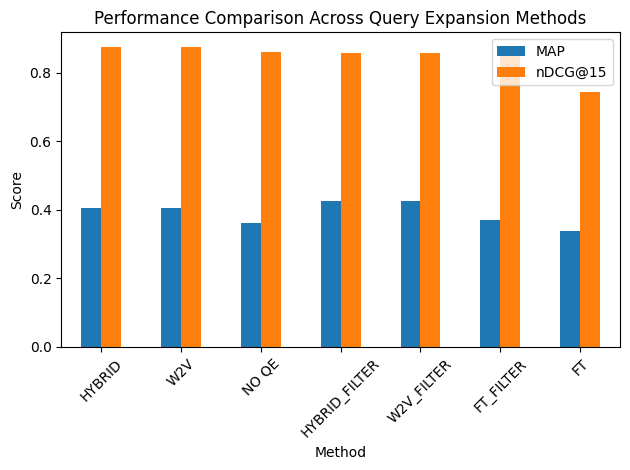

In [104]:
import matplotlib.pyplot as plt

# pastikan eval_df sudah ada dari kode kamu
df_plot = eval_df.set_index("system")

plt.figure()
df_plot[["MAP", "nDCG@15"]].plot(kind="bar")

plt.xlabel("Method")
plt.ylabel("Score")
plt.title("Performance Comparison Across Query Expansion Methods")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

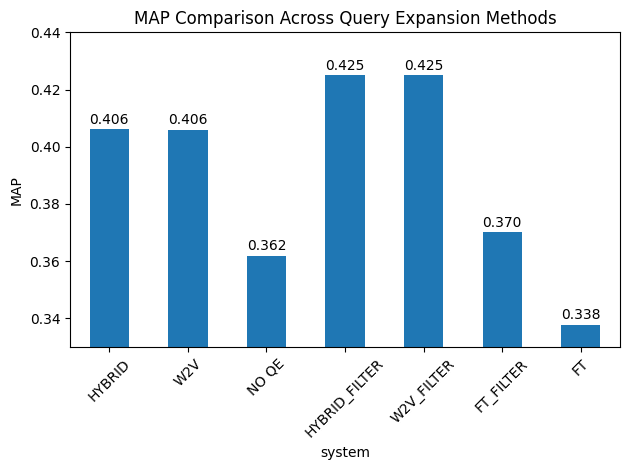

In [116]:
plt.figure()

df_plot["MAP"].plot(kind="bar")

plt.ylabel("MAP")
plt.title("MAP Comparison Across Query Expansion Methods")

# 🔥 zoom biar gap keliatan
plt.ylim(0.33, 0.44)

# 🔥 kasih label angka
for i, v in enumerate(df_plot["MAP"]):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

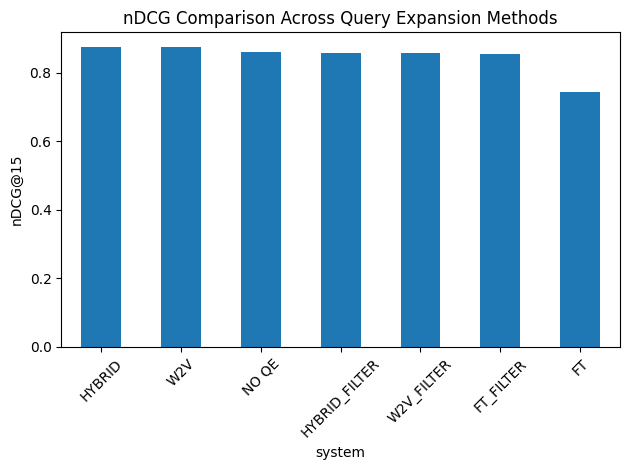

In [117]:
plt.figure()

df_plot["nDCG@15"].plot(kind="bar")

plt.ylabel("nDCG@15")
plt.title("nDCG Comparison Across Query Expansion Methods")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

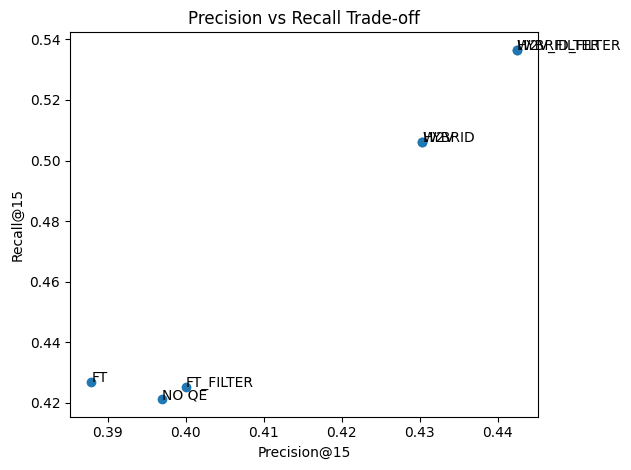

In [105]:
plt.figure()

plt.scatter(eval_df["P@15"], eval_df["R@15"])

for i, row in eval_df.iterrows():
    plt.text(row["P@15"], row["R@15"], row["system"])

plt.xlabel("Precision@15")
plt.ylabel("Recall@15")
plt.title("Precision vs Recall Trade-off")
plt.tight_layout()

plt.show()

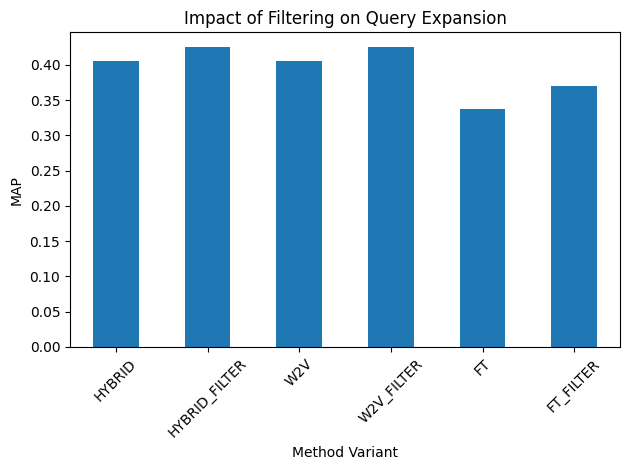

In [107]:
import pandas as pd

# ambil pasangan penting
ablation = eval_df.set_index("system").loc[
    ["HYBRID", "HYBRID_FILTER", "W2V", "W2V_FILTER", "FT", "FT_FILTER"]
]

plt.figure()
ablation["MAP"].plot(kind="bar")

plt.xlabel("Method Variant")
plt.ylabel("MAP")
plt.title("Impact of Filtering on Query Expansion")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [108]:
print(eval_df.round(4).to_latex(index=False))

\begin{tabular}{lrrrr}
\toprule
system & P@15 & R@15 & MAP & nDCG@15 \\
\midrule
HYBRID & 0.430300 & 0.506200 & 0.406100 & 0.874700 \\
W2V & 0.430300 & 0.506200 & 0.405800 & 0.874600 \\
NO QE & 0.397000 & 0.421200 & 0.361900 & 0.861500 \\
HYBRID_FILTER & 0.442400 & 0.536600 & 0.424900 & 0.858700 \\
W2V_FILTER & 0.442400 & 0.536600 & 0.424900 & 0.858700 \\
FT_FILTER & 0.400000 & 0.425400 & 0.370000 & 0.854700 \\
FT & 0.387900 & 0.426700 & 0.337800 & 0.744700 \\
\bottomrule
\end{tabular}



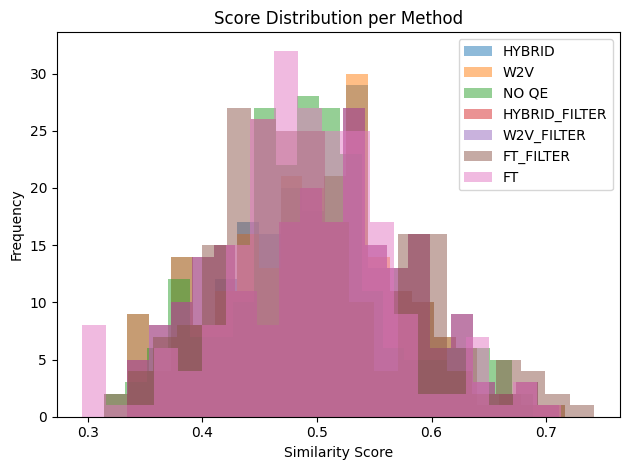

In [109]:
plt.figure()

for sys in eval_df["system"]:
    subset = df[df["system"] == sys]
    plt.hist(subset["score"], bins=20, alpha=0.5, label=sys)

plt.legend()
plt.title("Score Distribution per Method")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.tight_layout()

plt.show()

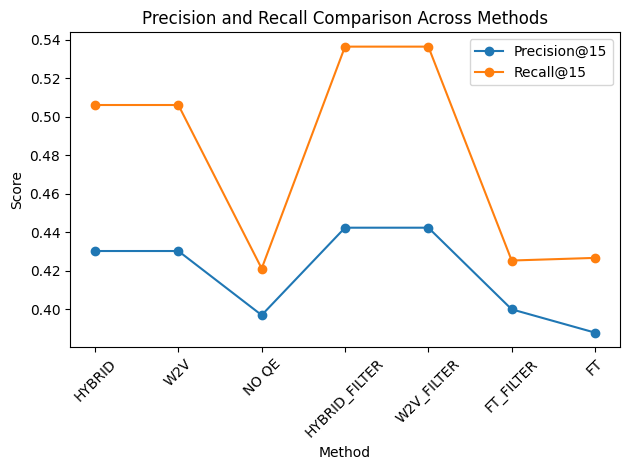

In [110]:
plt.figure()

plt.plot(eval_df["system"], eval_df["P@15"], marker='o', label="Precision@15")
plt.plot(eval_df["system"], eval_df["R@15"], marker='o', label="Recall@15")

plt.xlabel("Method")
plt.ylabel("Score")
plt.title("Precision and Recall Comparison Across Methods")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()


C:\Users\dela puspita\AppData\Local\Temp\ipykernel_15912\2321950477.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


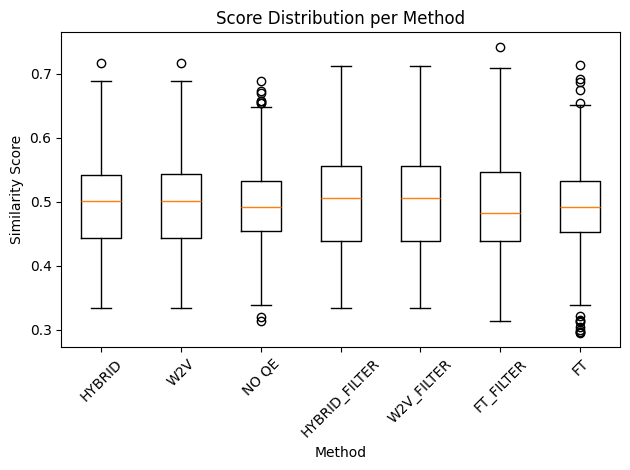

In [111]:
plt.figure()

data = []
labels = []

for sys in eval_df["system"]:
    subset = df[df["system"] == sys]["score"]
    data.append(subset)
    labels.append(sys)

plt.boxplot(data, labels=labels)

plt.xlabel("Method")
plt.ylabel("Similarity Score")
plt.title("Score Distribution per Method")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

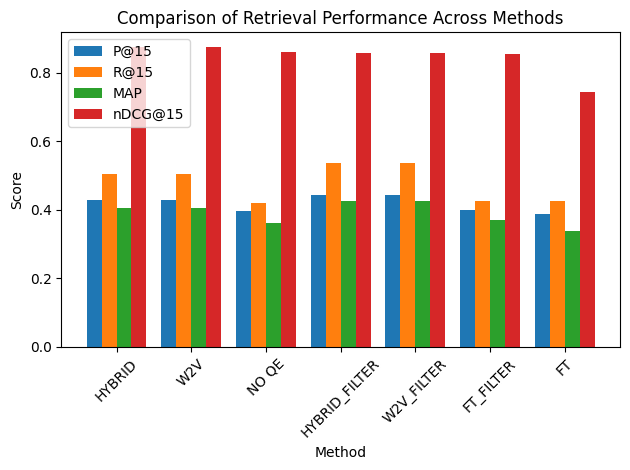

In [112]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["P@15", "R@15", "MAP", "nDCG@15"]
x = np.arange(len(eval_df["system"]))
width = 0.2

plt.figure()

for i, m in enumerate(metrics):
    plt.bar(x + i*width, eval_df[m], width, label=m)

plt.xticks(x + width*1.5, eval_df["system"], rotation=45)
plt.xlabel("Method")
plt.ylabel("Score")
plt.title("Comparison of Retrieval Performance Across Methods")
plt.legend()
plt.tight_layout()

plt.show()

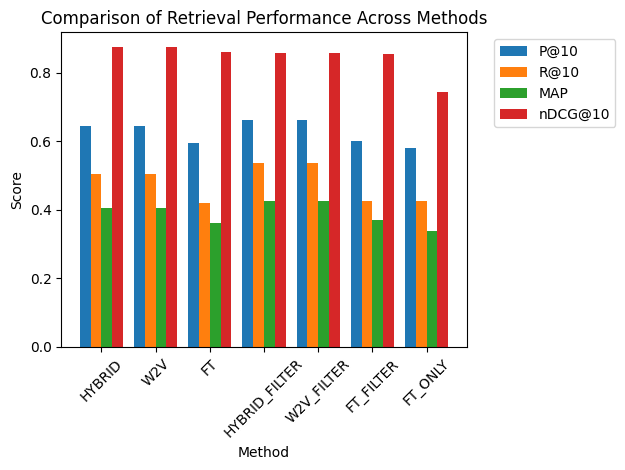

In [88]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["P@10", "R@10", "MAP", "nDCG@10"]
x = np.arange(len(eval_df["system"]))
width = 0.2

plt.figure()

for i, m in enumerate(metrics):
    plt.bar(x + i*width, eval_df[m], width, label=m)

plt.xticks(x + width*1.5, eval_df["system"], rotation=45)
plt.xlabel("Method")
plt.ylabel("Score")
plt.title("Comparison of Retrieval Performance Across Methods")

# 🔥 INI KUNCINYA
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

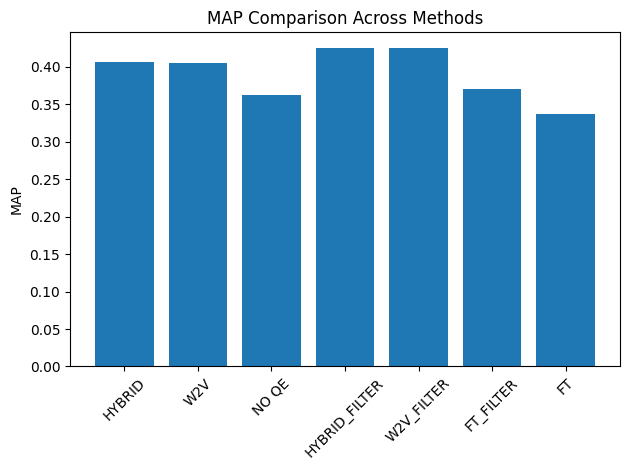

In [113]:
plt.figure()
plt.bar(eval_df["system"], eval_df["MAP"])

plt.ylabel("MAP")
plt.title("MAP Comparison Across Methods")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

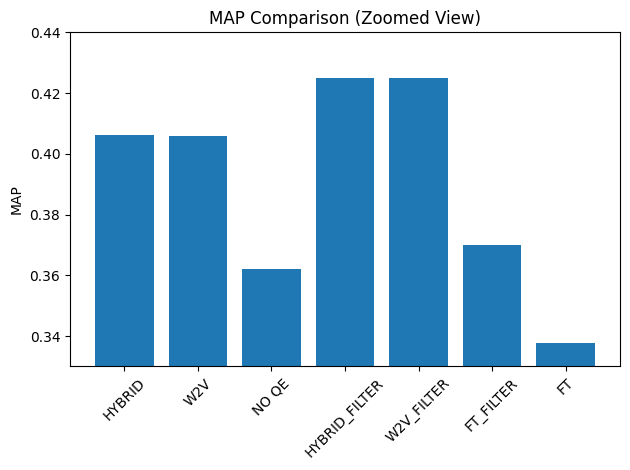

In [114]:
plt.figure()
plt.bar(eval_df["system"], eval_df["MAP"])

plt.ylim(0.33, 0.44)  # zoom range kamu

plt.ylabel("MAP")
plt.title("MAP Comparison (Zoomed View)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

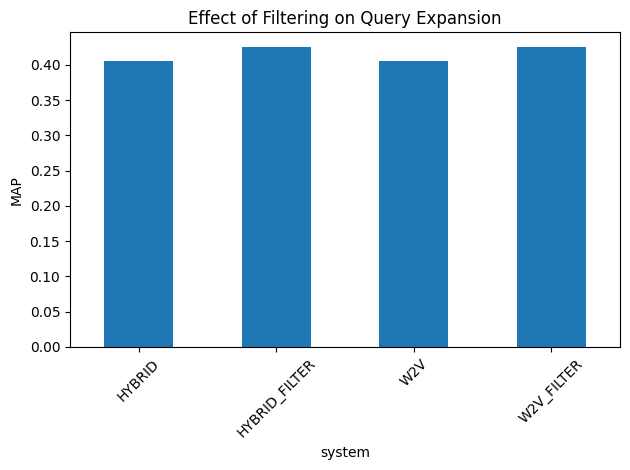

In [115]:
methods = ["HYBRID", "HYBRID_FILTER", "W2V", "W2V_FILTER"]

subset = eval_df.set_index("system").loc[methods]

plt.figure()
subset["MAP"].plot(kind="bar")

plt.ylabel("MAP")
plt.title("Effect of Filtering on Query Expansion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()